In [2]:
# Import neccesary libraries.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import randint

# Current Approach in improving performance
 - Remove Outliers
 - Remove high dependent variables
 - Use regularization methods
 - Use deep neural networks
 - check assumption
 - Transform the response variable for stable distribution
 - Create more measures (utilities) from the data (e.g. Star Powers)

### Load data and check response distribution

In [25]:
df = pd.read_csv("data/movie_data_encoded.csv")
y = df['revenue']
columns_to_drop = ['status', 'Unnamed: 0', 'name', 'genres', 'directors', 'writers','actors', 'original_language', 'production_companies',
       'release_date','keywords', 'revenue']
X = df.drop(columns_to_drop, axis=1)
y_log = np.log1p(y)

In [26]:
X.head()

,averageRating,numVotes,budget,runtime,trailer_views,trailer_likes,titleType_movie,titleType_tvMovie,director_score,writer_score,...,production_popular,lang_en,lang_fr,lang_es,lang_hi,lang_ja,lang_other,has_trailer,has_keywords,keyword_embedding
0,5.5,71.0,6.967033e+07,95.0,2.021111e+06,7.930411e+05,1.0,0.0,0,0,...,0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1,0.160210
1,5.8,117.0,0.000000e+00,110.0,-8.548080e+05,8.382362e+05,1.0,0.0,0,0,...,0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1,0.146542
2,6.1,27298.0,3.105832e+06,193.0,6.904190e+06,3.549670e+06,1.0,0.0,0,0,...,0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1,0.248196
3,6.5,2932.0,5.376505e+05,59.0,3.040960e+04,4.040880e+04,1.0,0.0,1,0,...,1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0,-1.267071
4,5.3,85.0,4.692912e+05,45.0,1.556221e+04,4.354229e+04,1.0,0.0,1,1,...,0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1,-0.141316


In [27]:
def check_revenue_distribution(series):
    plt.figure(figsize=(8,5))
    sns.histplot(series, bins=50, kde=True)
    plt.title("Revenue Distribution")
    plt.show()

In [28]:
# In million
round(y.describe() / 1e6, 2)

count      0.01
mean      27.37
std       44.03
min        0.00
25%        2.29
50%       13.36
75%       34.95
max      908.01
Name: revenue, dtype: float64

In [29]:
round(X['star_score'].describe(), 2)

count    11362.00
mean        75.79
std        126.70
min          0.00
25%          0.00
50%          0.00
75%        107.00
max       1566.00
Name: star_score, dtype: float64

In [30]:
#check_revenue_distribution(y)

In [31]:
#check_revenue_distribution(y_log)

### Transform Data and do train/test split

In [32]:
# Check VIF of each variable
vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i)
              for i in range(len(X.columns))]

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


In [33]:
vif

,feature,VIF
0,averageRating,1.547747e+00
1,numVotes,1.711249e+00
2,budget,2.083091e+00
3,runtime,1.471374e+00
4,trailer_views,2.039399e+00
5,trailer_likes,2.478649e+00
6,titleType_movie,9.007199e+15
7,titleType_tvMovie,9.007199e+15
8,director_score,1.833819e+00
9,writer_score,1.502340e+00


In [34]:
for i in vif[vif["VIF"] > 10]['feature']:
    X.drop(i, axis=1)

In [35]:
# Split original data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply log1p to y_train only
y_train_log = np.log1p(y_train)  # Train on log-transformed target

# Create polynomial features (For complex interaction)
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

feature_names = poly.get_feature_names_out(X.columns)

# Scale features using training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaler_poly = StandardScaler()
X_train_poly_scaled = scaler_poly.fit_transform(X_train_poly)
X_test_poly_scaled = scaler_poly.transform(X_test_poly)

### Dummy model performance

In [36]:
# Check the performance of the dummy variable
dummy_pred = np.full_like(y_test, y_train.mean())
RMSE = np.sqrt(mean_squared_error(y_test, dummy_pred))
R2 = r2_score(y_test, dummy_pred)

# Format RMSE (e.g., in millions)
print(f"RMSE: {round(RMSE / 1e6, 2)} Millions, R²: {round(R2, 2)}")

RMSE: 41.46 Millions, R²: -0.0


### Random Forest Regressor

In [37]:
'''
RFR_tune = RandomForestRegressor()
param_dist = {
    'n_estimators': [100, 300, 500, 1000],
    'max_depth': [5, 10, 20, 30, None],
    'min_samples_split': [2, 5, 10],  # Prevents overfitting
    'min_samples_leaf': [1, 2, 4],  # Controls minimum samples per leaf
    'max_features': ['sqrt', 'log2', 0.5, None]  # Feature selection method
}

rand_search = RandomizedSearchCV(RFR_tune, param_distributions=param_dist, n_iter=10, cv=5, random_state=42, n_jobs=-1)

# Fit the random search object to the data.
rand_search.fit(X_train_poly_scaled, y_train_log.values.ravel())
rand_search.best_estimator_
'''

"\nRFR_tune = RandomForestRegressor()\nparam_dist = {\n    'n_estimators': [100, 300, 500, 1000],\n    'max_depth': [5, 10, 20, 30, None],\n    'min_samples_split': [2, 5, 10],  # Prevents overfitting\n    'min_samples_leaf': [1, 2, 4],  # Controls minimum samples per leaf\n    'max_features': ['sqrt', 'log2', 0.5, None]  # Feature selection method\n}\n\nrand_search = RandomizedSearchCV(RFR_tune, param_distributions=param_dist, n_iter=10, cv=5, random_state=42, n_jobs=-1)\n\n# Fit the random search object to the data.\nrand_search.fit(X_train_poly_scaled, y_train_log.values.ravel())\nrand_search.best_estimator_\n"

In [38]:
RFR = RandomForestRegressor(max_depth=20, max_features=0.5, min_samples_leaf=4, min_samples_split=5, n_estimators=500, oob_score=True, random_state=42)
RFR.fit(X_train_poly_scaled, y_train_log.values.ravel())
#y_pred = RFR.predict(X_test_poly_scaled)
y_pred = np.expm1(RFR.predict(X_test_poly_scaled))
RMSE = np.sqrt(mean_squared_error(y_test, y_pred))
R2 = r2_score(y_test, y_pred)
# Format RMSE (e.g., in millions)
print(f"RMSE: {round(RMSE / 1e6, 2)} Millions, R²: {round(R2, 2)}")

RMSE: 29.04 Millions, R²: 0.51


In [39]:
RFR.oob_score_

0.9517219464276571

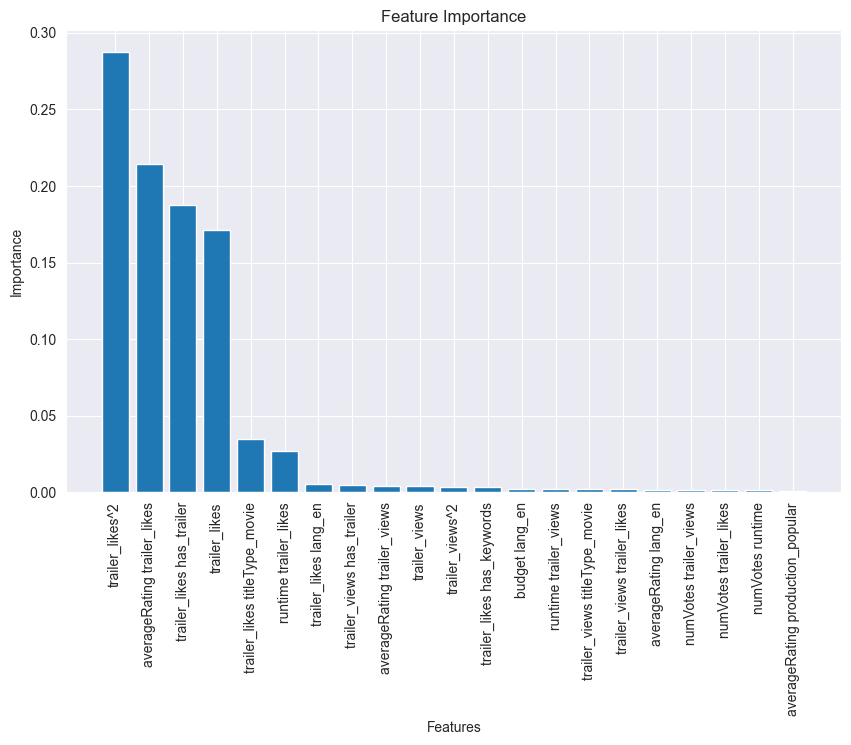

In [40]:
importances = RFR.feature_importances_

feature_importances = pd.DataFrame(RFR.feature_importances_, index=feature_names, columns=["importance"]).sort_values("importance", ascending=False)

# Select important features (importance >= 0.05)
important_features = feature_importances[feature_importances["importance"] >= 0.001].index

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.title("Feature Importance")

# Get corresponding importance values
important_importance_values = feature_importances.loc[important_features, "importance"]

# Plot
plt.bar(range(len(important_features)), important_importance_values, align="center")
plt.xticks(range(len(important_features)), important_features, rotation=90)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [41]:
# Map feature names to column indices
important_feature_indices = [i for i, name in enumerate(feature_names) if name in important_features]

# Select only important features using integer indices
X_train_poly_scaled = X_train_poly_scaled[:, important_feature_indices]
X_test_poly_scaled = X_test_poly_scaled[:, important_feature_indices]

In [42]:
X_train_poly_scaled.shape

(9089, 21)

In [43]:
X_test_poly_scaled.shape

(2273, 21)

### Boosting Methods

In [44]:
'''
GDB_tune = GradientBoostingRegressor()
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of boosting stages
    'learning_rate': [0.01, 0.1, 0.2],  # Step size shrinkage
    'max_depth': [3, 5, 7],  # Depth of each tree
    'min_samples_split': [2, 5, 10],  # Minimum samples to split an internal node
    'min_samples_leaf': [1, 2, 4],  # Minimum samples at a leaf node
    'subsample': [0.8, 1.0],  # Fraction of samples used for training each tree
    'max_features': ['sqrt', 'log2', None]  # Number of features per tree
}

rand_search = RandomizedSearchCV(GDB_tune, param_distributions=param_grid, cv=5, n_jobs=1)

# Fit the random search object to the data.
rand_search.fit(X_train_poly_scaled, y_train_log.values.ravel())
rand_search.best_estimator_'
'''

"\nGDB_tune = GradientBoostingRegressor()\nparam_grid = {\n    'n_estimators': [50, 100, 200],  # Number of boosting stages\n    'learning_rate': [0.01, 0.1, 0.2],  # Step size shrinkage\n    'max_depth': [3, 5, 7],  # Depth of each tree\n    'min_samples_split': [2, 5, 10],  # Minimum samples to split an internal node\n    'min_samples_leaf': [1, 2, 4],  # Minimum samples at a leaf node\n    'subsample': [0.8, 1.0],  # Fraction of samples used for training each tree\n    'max_features': ['sqrt', 'log2', None]  # Number of features per tree\n}\n\nrand_search = RandomizedSearchCV(GDB_tune, param_distributions=param_grid, cv=5, n_jobs=1)\n\n# Fit the random search object to the data.\nrand_search.fit(X_train_poly_scaled, y_train_log.values.ravel())\nrand_search.best_estimator_'\n"

In [45]:
GDB = GradientBoostingRegressor(max_depth=5, max_features='sqrt', min_samples_leaf=2, min_samples_split=10, n_estimators=200, subsample=0.8, random_state=42)
GDB.fit(X_train_poly_scaled, y_train_log.values.ravel())
#y_pred = GDB.predict(X_test_poly_scaled)
y_pred = np.expm1(GDB.predict(X_test_poly_scaled))
RMSE = np.sqrt(mean_squared_error(y_test, y_pred))
R2 = r2_score(y_test, y_pred)
# Format RMSE (e.g., in millions)wwww
print(f"RMSE: {round(RMSE / 1e6, 2)} Millions, R²: {round(R2, 2)}")

RMSE: 28.43 Millions, R²: 0.53


### Muti-Layer Perceptron 

In [46]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim, dropout=0.2):
        super(MLP, self).__init__()
        layers = []
        last_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(last_dim, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))  # Stabilize training
            layers.append(nn.ELU(alpha=1.0))
            layers.append(nn.Dropout(dropout))    # Regularization
            last_dim = h_dim
        layers.append(nn.Linear(last_dim, output_dim))
        self.model = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.model(x)

input_dim = 20      # Number of input features
hidden_dims = [64,32]  # Two hidden layers with 64 and 32 neurons
output_dim = 1      # For regression 

model = MLP(input_dim, hidden_dims, output_dim)
print(model)

# Now, split train and validation
X_train_poly_scaled, X_val_poly_scaled, y_train_log, y_val_log = train_test_split(
    X_train_poly_scaled, y_train_log, test_size=0.3, random_state=42
)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_poly_scaled, dtype=torch.float)
X_val_tensor = torch.tensor(X_val_poly_scaled, dtype=torch.float)
X_test_tensor = torch.tensor(X_test_poly_scaled, dtype=torch.float)

y_train_tensor = torch.tensor(y_train_log.values, dtype=torch.float).view(-1, 1)
y_val_tensor = torch.tensor(y_val_log.values, dtype=torch.float).view(-1, 1)
y_test_log = np.log1p(y_test)  # Keep test log-transformed for loss calculation
y_test_tensor = torch.tensor(y_test_log.values, dtype=torch.float).view(-1, 1)

# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.1, weight_decay=1e-4)  # L2 regularization

# Early stopping parameters
best_val_loss = float('inf')  # Store best loss (initially very high)
patience = 1000             # Stop if no improvement for `patience` epochs
epochs_without_improvement = 0  

# Training loop
num_epochs = 10000
for epoch in range(num_epochs):
    if epoch > 1000: # Fine tuning
        for param_group in optimizer.param_groups:
            param_group["lr"] = 0.01
    elif epoch > 3000:
        for param_group in optimizer.param_groups:
            param_group["lr"] = 0.0001

    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()

    # Validate
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor).item()  # Convert tensor to scalar

    # Early stopping logic
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0  # Reset counter
    else:
        epochs_without_improvement += 1
        
    # Check if early stopping criteria is met
    if epochs_without_improvement >= patience:
        print(f"Early stopping at epoch {epoch+1}, best validation loss: {best_val_loss:.4f}")
        break

    # Print progress every 1000 epochs
    if (epoch + 1) % 1000 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Train Loss: {loss.item():.4f}, Val Loss: {val_loss:.4f}')

MLP(
  (model): Sequential(
    (0): Linear(in_features=20, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ELU(alpha=1.0)
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ELU(alpha=1.0)
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)


RuntimeError: mat1 and mat2 shapes cannot be multiplied (6362x21 and 20x64)

In [47]:
# Evaluation
model.eval()
with torch.no_grad():
    test_outputs_log = model(X_test_tensor)

    # Compute test loss in log space
    test_loss = criterion(test_outputs_log, y_test_tensor)

    # Convert both predictions and ground truth back to original scale
    test_outputs = torch.expm1(test_outputs_log)  # Predictions in original scale
    y_test_original = torch.expm1(y_test_tensor)  # Ground truth in original scale

    # Compute RMSE in original scale
    mse = torch.mean((test_outputs - y_test_original) ** 2)
    rmse = torch.sqrt(mse) / 1e6  # Convert RMSE to millions

    # Compute R² in original scale
    ss_res = torch.sum((y_test_original - test_outputs) ** 2)
    ss_tot = torch.sum((y_test_original - torch.mean(y_test_original)) ** 2)
    r2 = 1 - (ss_res / ss_tot)

print(f'Test Loss (Log Scale): {test_loss.item():.4f}, RMSE: {rmse.item():.4f} Millions, R²: {r2.item():.4f}')

RuntimeError: mat1 and mat2 shapes cannot be multiplied (2273x21 and 20x64)